Import Libraries

In [38]:
import numpy as np # For numerical operations
import pandas as pd # For data manipulation and analysis
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations
import seaborn as sns # For statistical data visualization
from sklearn.model_selection import train_test_split # For splitting data into training and testing sets
from sklearn.linear_model import LinearRegression # For building the linear regression model

Load Dataset


In [39]:
df =pd.read_csv('/content/Salary Data.csv') # Load the dataset into a pandas DataFrame
df # Display the entire DataFrame

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


Exploratory Data Analysis (EDA)

In [40]:
df.head(5) # Display the first 5 rows of the DataFrame

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [41]:
df.tail(5) # Display the last 5 rows of the DataFrame

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [ ]:
# Check dataset information
print(df.info())

# Statistical summary
print(df.describe())

# Check for missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000
YearsExperience    0
Salary             0
dtype: int64


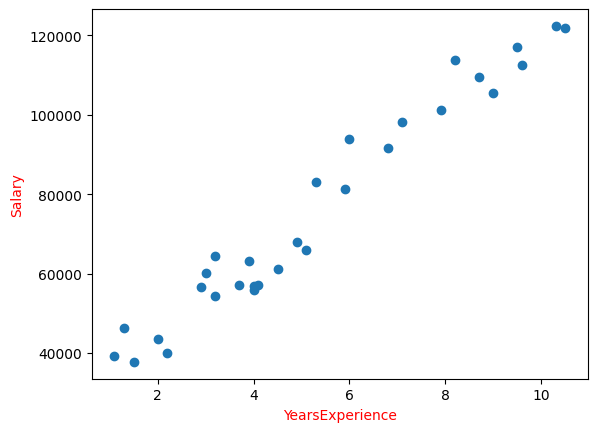

In [42]:
plt.xlabel('YearsExperience', color = 'red') # Set x-axis label
plt.ylabel('Salary', color = 'red') # Set y-axis label
plt.scatter(df['YearsExperience'],df['Salary']) # Create a scatter plot of YearsExperience vs. Salary
plt.show() # Display the plot

Prepare Data for Modeling

In [43]:
# Separate features (X) and target (y)
x = df[['YearsExperience']] # Features are the 'YearsExperience' column
y = df['Salary'] # Target is the 'Salary' column

print(f"Features shape: {x.shape}") # Print the shape of the features DataFrame
print(f"Target shape: {y.shape}") # Print the shape of the target Series

# Split data into training and testing sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) # Split data with a test size of 20% and a fixed random state for reproducibility


print(f"\nTraining set size: {x_train.shape[0]}") # Print the number of samples in the training set
print(f"Testing set size: {x_test.shape[0]}") # Print the number of samples in the testing set

Features shape: (30, 1)
Target shape: (30,)

Training set size: 24
Testing set size: 6


Train the Linear Regression Model

In [44]:
lreg = LinearRegression() # Initialize the Linear Regression model
lreg.fit(x_train, y_train) # Train the model using the training data

LinearRegression()

In [35]:
# Predict on training and test data
y_train_pred = lreg.predict(x_train)
y_test_pred = lreg.predict(x_test)


In [45]:
lreg.predict([[16]]) # Predict the salary for 16 years of experience

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([176102.62818027])

In [36]:
# Create DataFrame with actual vs predicted values
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Difference': y_test - y_test_pred
})
print("\nTest Set - Actual vs Predicted:")
print(comparison_df)


Test Set - Actual vs Predicted:
      Actual      Predicted    Difference
27  112635.0  115790.210113  -3155.210113
15   67938.0   71498.278095  -3560.278095
23  113812.0  102596.868661  11215.131339
17   83088.0   75267.804224   7820.195776
8    64445.0   55477.792045   8967.207955
9    57189.0   60189.699707  -3000.699707


In [46]:
lreg.score(df[['YearsExperience']], df['Salary']) # Calculate the R-squared score of the model on the full dataset

0.9564379197293564

In [47]:
lreg.coef_ # Get the coefficient (slope) of the linear regression model

array([9423.81532303])

In [48]:
lreg.intercept_ # Get the intercept of the linear regression model

np.float64(25321.583011776813)

In [49]:
lreg.coef_*16 + lreg.intercept_ # Manually calculate the predicted salary for 16 years of experience using the learned coefficients

array([176102.62818027])

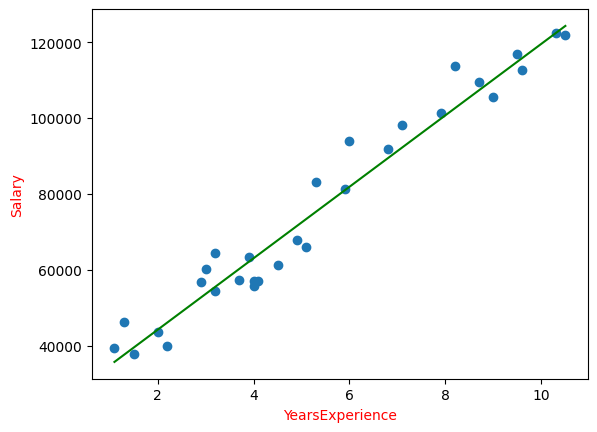

In [50]:
plt.xlabel('YearsExperience', color = 'red') # Set x-axis label
plt.ylabel('Salary', color = 'red') # Set y-axis label
plt.scatter(df['YearsExperience'],df['Salary']) # Create a scatter plot of the original data
plt.plot(df['YearsExperience'], lreg.predict(df[['YearsExperience']]), color = 'green') # Plot the regression line
plt.show() # Display the plot